# NICHEVERSE on Vizgen MERFISH

**Platform.** Vizgen MERSCOPE / MERFISH (imaging based, targeted gene panel).

**Dataset (real).** Mouse retina MERFISH (Vizgen 2023 release), bundled with the package at
`examples/data/merfish_retina.h5ad`: **113,385 cells x 368 genes, 4 samples**. Prepared from
`datasetsg/merfish/mouse_retina_2023/VZA105a_integrated_368genes.h5ad` (see
`tmp/prep_platform_adata.py::build_merfish`). Raw integer counts are in `.X`, micron
centroids in `obsm['spatial']`, and `obs['sample_id']` holds the four MERFISH runs.

**Units.** `obsm['spatial']` is in **microns** (the MERFISH `global_x` / `global_y` stage
coordinates).

The bundled AnnData ships segmented counts only (no per-molecule table), so this notebook
trains on segmented expression. If you have the Vizgen `detected_transcripts.csv`
(columns `global_x`, `global_y`, `gene`), you can add a transcript-context input exactly as
in the Xenium notebook by passing `platform="merfish"`. Real runs use about 300 epochs.


In [1]:
import anndata as ad, numpy as np
PLATFORM = "MERFISH (mouse retina)"
adata = ad.read_h5ad("/data1/lesliec/vijay/github/nicheverse/examples/data/merfish_retina.h5ad")
assert "spatial" in adata.obsm and "sample_id" in adata.obs
print(adata)
print("samples:", list(adata.obs["sample_id"].unique()),
      "| n_genes:", adata.n_vars,
      "| spatial units ~microns:", adata.obsm["spatial"].max(0).round(0))


AnnData object with n_obs × n_vars = 113385 × 368
    obs: 'sample_id'
    obsm: 'spatial'
samples: ['VZG105a_WT1', 'VZG105a_WT2', 'VZG105a_WT3', 'VZG105a_WT4'] | n_genes: 368 | spatial units ~microns: [8611. 7697.]


## Configure and train

We build a `ModelConfig` (the architecture) and a `TrainConfig` (the optimization / spatial graph), then call `train_model`. The current library default encoder is `mlp_plr` (per-gene piecewise-linear embeddings) with the `vq` quantizer, and the neighborhood graph is `knn_radius` (radius 50 um, k = 20). We keep `batch_size=2048` rather than `'auto'`, because an over-large auto batch shrinks the number of optimizer steps per epoch and starves the codebook-diversity term. We run only a handful of demo epochs here so the notebook finishes in minutes; a production run uses about 300 epochs.

In [2]:
import os
from nicheverse.models import ModelConfig, HierarchicalVQVAE
from nicheverse.training import train_model, TrainConfig

ckpt = "/data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/nb_merfish_demo"
os.makedirs(ckpt, exist_ok=True)

mc = ModelConfig(
    input_dim=int(adata.n_vars),
    cell_embedding_dim=64, cell_num_embeddings=256,
    neighborhood_embedding_dim=256, neighborhood_num_embeddings=32,
    use_cross_attention=True,
    gene_names=tuple(adata.var_names.astype(str)),
    encoder_type="mlp_plr", quantizer_type="vq",   # library default; shines on a diverse cohort
)
tc = TrainConfig(
    num_epochs=30,             # demo; production ~300 (30 epochs already fills ~197/256 codes here)
    batch_size=2048,
    learning_rate=3e-4,
    spatial_graph="knn_radius", radius=50.0, k_neighbors=20,
    normalize=True, log1p=True, seed=49,
)
model, adata = train_model(adata, ckpt, model_config=mc, train_config=tc, sample_col="sample_id")
print("done ->", ckpt)


/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


epoch 1/30:   0%|          | 0/56 [00:00<?, ?it/s]

epoch 2/30:   0%|          | 0/56 [00:00<?, ?it/s]

epoch 3/30:   0%|          | 0/56 [00:00<?, ?it/s]

epoch 4/30:   0%|          | 0/56 [00:00<?, ?it/s]

...

epoch 27/30:   0%|          | 0/56 [00:00<?, ?it/s]

epoch 28/30:   0%|          | 0/56 [00:00<?, ?it/s]

epoch 29/30:   0%|          | 0/56 [00:00<?, ?it/s]

epoch 30/30:   0%|          | 0/56 [00:00<?, ?it/s]

done -> /data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/nb_merfish_demo


## Inspect the learned codebook

`train_model` writes the per-cell code assignment to `hierarchical_cell_indices.npz` (key `indices`). A healthy run spreads cells across many codes; a collapsed run puts almost everything in one code.

In [3]:

# --- Load the codes the model just assigned to every cell ---
import numpy as np, json, os
idx = np.load(os.path.join(ckpt, "hierarchical_cell_indices.npz"))["indices"].ravel()
n_codes = int(model.config.cell_num_embeddings)
u, counts = np.unique(idx, return_counts=True)
print(f"{PLATFORM}: {len(idx)} cells assigned to {len(u)}/{n_codes} cell codes "
      f"(codebook usage {100*len(u)/n_codes:.0f}%)")


MERFISH (mouse retina): 113385 cells assigned to 197/256 cell codes (codebook usage 77%)


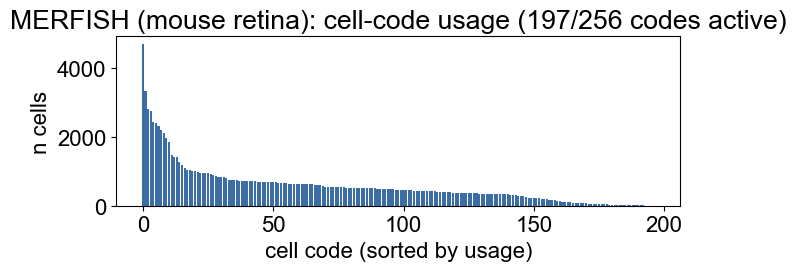

In [4]:

# --- Code-usage bar chart (how many cells fall in each active code) ---
%matplotlib inline
import matplotlib.pyplot as plt
order = np.argsort(counts)[::-1]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(u)), counts[order], color="#3b6ea5")
ax.set_xlabel("cell code (sorted by usage)")
ax.set_ylabel("n cells")
ax.set_title(f"{PLATFORM}: cell-code usage ({len(u)}/{n_codes} codes active)")
plt.tight_layout()
plt.show()


## Top markers per code

For each used code we z-score its mean expression across codes and list the most enriched panel genes. This is a quick biological sanity check that codes track distinct cell states.

In [5]:

# --- Per-code top-marker table: mean log1p expression per code, z-scored across codes ---
import pandas as pd, scanpy as sc
work = adata.copy()
sc.pp.normalize_total(work); sc.pp.log1p(work)
X = work.X.toarray() if hasattr(work.X, "toarray") else np.asarray(work.X)
genes = np.asarray(work.var_names)
rows = []
for c in u:                                   # only codes that are actually used
    m = X[idx == c].mean(0)
    rows.append(m)
M = np.vstack(rows)                            # (n_used_codes, n_genes)
Z = (M - M.mean(0)) / (M.std(0) + 1e-8)        # z across codes, per gene
topk = 6
recs = []
for r, c in enumerate(u):
    top = genes[np.argsort(Z[r])[::-1][:topk]]
    recs.append({"cell_code": int(c), "n_cells": int((idx == c).sum()),
                 "top_markers": ", ".join(top)})
marker_tbl = pd.DataFrame(recs).sort_values("n_cells", ascending=False).reset_index(drop=True)
print(f"Top {topk} enriched genes per used cell code (first 15 codes shown):")
marker_tbl.head(15)


Top 6 enriched genes per used cell code (first 15 codes shown):


,cell_code,n_cells,top_markers
0,120,4696,"Etv1, Slc7a11, Calml4, Penk, Tsc22d4, Pde1a"
1,167,3344,"Tulp1, Neurod1, Prom1, Nrl, Reep6, Nr2e3"
2,253,2804,"Neurod1, Ramp3, Prom1, Prokr1, C1ql3, Reep6"
3,55,2765,"Drd4, Reep6, Nr2e3, Prom1, Nrl, Tulp1"
4,254,2444,"Neurod1, Prom1, Tulp1, Nr2e3, Reep6, Prokr1"
5,172,2419,"Cngb1, Reep6, C1ql3, Susd3, Crx, Slc17a7"
6,131,2305,"Neurod1, Drd4, Prom1, Reep6, Nr2e3, Inadl"
7,161,2202,"Neurod1, Prokr1, Ceacam10, Tulp1, Nr2e3, Camta1"
8,108,2118,"Ramp3, Drd4, Lmo3, Pde6a, Lyar, Slc17a7"
9,193,1983,"Neurod1, Tulp1, Ramp3, Prom1, Nrl, Nr2e3"


## Training runtime

The trainer records wall-clock time, throughput (cells/sec), and peak GPU memory to `training_runtime.json`.

In [6]:

# --- Training runtime report the trainer wrote (real timing on this GPU run) ---
rt_path = os.path.join(ckpt, "training_runtime.json")
runtime = json.load(open(rt_path))
print(json.dumps(runtime, indent=2))


{
  "total_seconds": 44.754,
  "total_hms": "0:00:44",
  "n_epochs": 30,
  "mean_epoch_seconds": 1.492,
  "cells_per_second": 76005.97,
  "iters_per_second": 37.539,
  "n_cells": 113385,
  "effective_batch_size": 2048,
  "n_batches_per_epoch": 56,
  "peak_gpu_gb": 0.931,
  "device": "cuda",
  "encoder_type": "mlp_plr",
  "quantizer_type": "vq",
  "input_dim": 368
}
